# NeuroDecel — Brain Age Model Pipeline (Train/Test Split Version)

This version uses a single train/test split (as requested by the team) instead of
cross-validation. Steps:

1. Merge real W1 structural MRI data with age on `S#`
2. Build one clean feature table (no PCA — features stay named/interpretable)
3. Split into train (80%) / test (20%), stratified by age so both sets have a
   similar age spread
4. Train XGBoost on the training set
5. Apply bias correction (fit on train predictions only, applied to test predictions)
6. Compute brain-age-gap on the test set and plot predicted vs. actual age
7. Run SHAP for per-prediction, region-level explanations

Put `BIOMARKERDATA__2_.xlsx` in the same folder as this notebook before running.

**Note:** with only 464 subjects, a single 20% test set is ~93 people — small enough
that this number can shift a fair amount if you rerun with a different random seed.
See the note at the end of this notebook for why the team may want to revisit
cross-validation for the number that goes on the final slide.

## 1. Imports

In [13]:
pip install xgboost shap openpyxl scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# If any of these aren't installed, uncomment and run once:
# !pip install xgboost shap openpyxl scikit-learn matplotlib

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

# If notebook is running from /notebooks, go one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "dataset"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)

## 2. Load and merge the real W1 data

We join `AgeMRI_W1` (age at scan) to all five Wave 1 sheets on `S#`.
Metadata columns and constant flag columns are dropped — they're not real features.

In [ ]:
DATA_PATH = DATASET_DIR / "BIOMARKERDATA.xlsx"
META_COLS = ["AIRC_ID", "ConstructName", "Wave", "HasData", "NumScores"]
FLAG_COLS = ["Global", "Thickness", "Volume", "Area", "SubVolumes"]  # constant columns, not real features

def load_sheet(sheet_name):
    df = pd.read_excel(DATA_PATH, sheet_name=sheet_name)
    drop_cols = [c for c in META_COLS + FLAG_COLS if c in df.columns]
    return df.drop(columns=drop_cols)

# Age sheet - use AgeMRI_W1 (age at scan), not AgeCog_W1 (age at cognitive testing)
age_df = pd.read_excel(DATA_PATH, sheet_name="Age-W1,W2,W3")
age_w1 = age_df[["S#", "AgeMRI_W1"]].dropna(subset=["AgeMRI_W1"])

sheets_w1 = [
    "GlobalVariables-W1",
    "CorticalThickness-W1",
    "GMVolume-W1",
    "SurfaceArea-W1",
    "SubcorticalVolume-W1",
]

merged = age_w1.copy()
for s in sheets_w1:
    merged = merged.merge(load_sheet(s), on="S#", how="inner")

print("Merged shape:", merged.shape)
print("Missing values:", merged.isna().sum().sum())
merged.head()

Merged shape: (464, 272)
Missing values: 0


,S#,AgeMRI_W1,LhMeanThick,RhMeanThick,LhWhiteSurfArea,RhWhiteSurfArea,TotalIntracranialVol,CSFVol,WMHypointensitiesVol,NonWMHypointensitiesVol,...,RhVentralDCVol,RhVesselVol,RhChoroidPVol,FifthVentVol,OpticChiasmVol,CCPosteriorVol,CCMidPosteriorVol,CCCentralVol,CCMidAnteriorVol,CCAnteriorVol
0,12,56,2.33684,2.35982,89780.0,88297.2,1.401956e+06,1305.9,2222.2,12.8,...,3560.4,145.8,1477.4,1.6,157.1,878.1,297.0,304.4,351.8,680.1
1,21,72,2.41386,2.40320,71745.1,72470.5,1.421334e+06,706.7,1396.3,53.9,...,3484.0,149.5,1037.9,1.9,132.9,1276.4,484.8,453.1,490.0,937.5
2,49,70,2.75512,2.78113,68095.0,68974.8,1.441846e+06,1391.9,2441.4,37.4,...,3314.0,51.7,1954.6,4.0,97.6,958.9,317.4,335.2,371.8,708.6
3,61,55,2.77765,2.77940,68863.0,68811.4,1.380674e+06,1411.0,664.2,5.5,...,4434.0,61.8,867.1,0.0,191.9,996.6,493.8,716.3,532.0,778.8
4,80,41,3.03383,3.00712,93682.0,95287.6,1.836642e+06,1393.1,2316.1,16.5,...,4658.1,111.5,1273.1,12.8,213.6,1072.8,520.6,534.6,560.7,910.0


## 3. Build the feature table

No PCA — every column is a real, named brain region or global measure.
That's what lets SHAP point straight at a region name your evidence agent can look up.

In [16]:
feature_cols = [c for c in merged.columns if c not in ("S#", "AgeMRI_W1")]
X = merged[feature_cols].values
y = merged["AgeMRI_W1"].values
ids = merged["S#"].values

print(f"{X.shape[0]} subjects, {X.shape[1]} named features, age range {y.min():.0f}-{y.max():.0f}")

464 subjects, 270 named features, age range 21-89


## 4. Train / test split

80% train, 20% test — stratified by age quartile so the test set isn't accidentally
skewed toward one age group.

In [17]:
age_bins = pd.qcut(y, 4, labels=False)  # 4 age groups, used only to balance the split

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, ids, test_size=0.2, random_state=42, stratify=age_bins
)

print(f"Train: {X_train.shape[0]} subjects   Test: {X_test.shape[0]} subjects")

Train: 371 subjects   Test: 93 subjects


## 5. Train XGBoost + apply bias correction

The bias-correction line (`predicted age → actual age`) is fit **only on the training
set's own predictions**, then applied to the test set. This avoids leakage — the
correction never sees the test data it's being applied to.

In [18]:
xgb_params = dict(
    n_estimators=2000,
    max_depth=3,           # shallow trees - guards against overfitting on ~370 training rows
    learning_rate=0.005,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.75,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
)

model = xgb.XGBRegressor(**xgb_params)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Bias correction: fit on TRAIN predictions only, apply to TEST predictions
bias_model = LinearRegression()
bias_model.fit(train_pred.reshape(-1, 1), y_train - train_pred)
correction = bias_model.predict(test_pred.reshape(-1, 1))
test_pred_corrected = test_pred + correction

mae_raw = mean_absolute_error(y_test, test_pred)
mae_corr = mean_absolute_error(y_test, test_pred_corrected)
corr_raw = pearsonr(y_test, test_pred)[0]
corr_corr = pearsonr(y_test, test_pred_corrected)[0]

print(f"Raw:       MAE={mae_raw:.2f}  correlation={corr_raw:.3f}")
print(f"Corrected: MAE={mae_corr:.2f}  correlation={corr_corr:.3f}")

Raw:       MAE=7.24  correlation=0.876
Corrected: MAE=7.15  correlation=0.876


## 6. Brain-age-gap on the test set

`brain_age_gap = predicted_age - actual_age`. Positive = predicted older than actual,
negative = predicted younger than actual. This is the per-person deliverable your
evidence layer and clinician review loop will consume.

In [ ]:
brain_age_gap = test_pred_corrected - y_test

results_df = pd.DataFrame({
    "S#": ids_test,
    "actual_age": y_test,
    "predicted_age": test_pred_corrected,
    "brain_age_gap": brain_age_gap,
}).sort_values("S#").reset_index(drop=True)

results_df.to_csv(
    OUTPUTS_DIR / "test_set_brain_age_gap.csv",
    index=False
)
print(f"Saved {len(results_df)} test-set predictions to test_set_brain_age_gap.csv")
results_df.head(10)

Saved 93 test-set predictions to test_set_brain_age_gap.csv


,S#,actual_age,predicted_age,brain_age_gap
0,21,72,65.097305,-6.902695
1,81,41,46.233177,5.233177
2,101,44,52.964169,8.964169
3,147,51,55.196281,4.196281
4,149,68,55.004837,-12.995163
5,183,62,37.594826,-24.405174
6,192,30,35.525913,5.525913
7,257,76,69.665672,-6.334328
8,295,71,78.088364,7.088364
9,383,71,69.856354,-1.143646


## 7. Plot: predicted age vs. actual age (test set)

Points near the red dashed line (y = x) are accurate predictions. Points above the
line are predicted older than actual; points below are predicted younger.

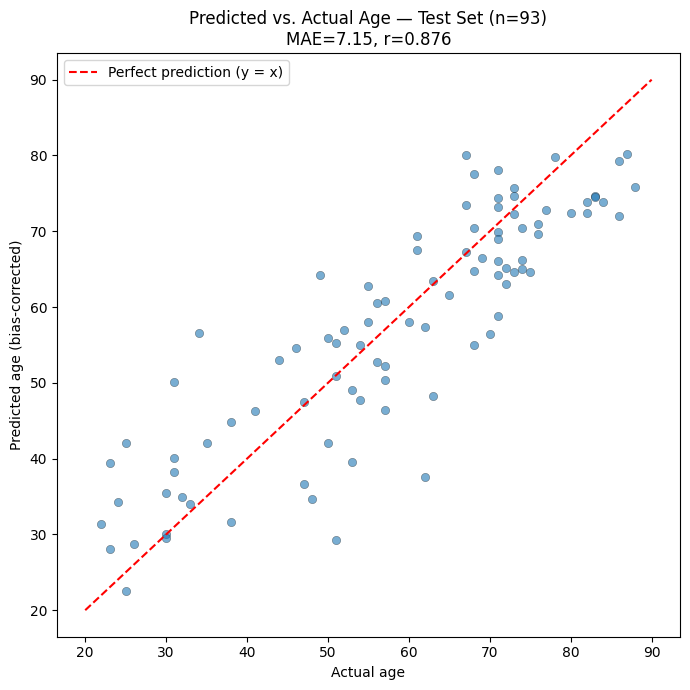

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_pred_corrected, alpha=0.6, edgecolor="k", linewidth=0.3)

lims = [min(y_test.min(), test_pred_corrected.min()) - 2,
        max(y_test.max(), test_pred_corrected.max()) + 2]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")

plt.xlabel("Actual age")
plt.ylabel("Predicted age (bias-corrected)")
plt.title(f"Predicted vs. Actual Age — Test Set (n={len(y_test)})\nMAE={mae_corr:.2f}, r={corr_corr:.3f}")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUTS_DIR / "predicted_vs_actual_test.png",
    dpi=150
)
plt.show()

## 8. Sanity check: accuracy by age quartile

Checks whether the test set shows the same "worse at the extremes" pattern seen
in the cross-validated version.

In [21]:
test_age_quartiles = pd.qcut(y_test, 4, labels=["Q1 (youngest)", "Q2", "Q3", "Q4 (oldest)"])
quartile_check = pd.DataFrame({
    "age_quartile": test_age_quartiles,
    "abs_error": np.abs(brain_age_gap),
})
quartile_check.groupby("age_quartile", observed=True)["abs_error"].agg(["mean", "count"])

,mean,count
age_quartile,,
Q1 (youngest),7.715568,24
Q2,6.929619,23
Q3,6.961060,24
Q4 (oldest),6.990478,22


## 9. SHAP (region-level explanations)

Trained on the same model used for test predictions above. SHAP values point
directly at named brain regions — no PCA translation step needed.

In [22]:
explainer = shap.TreeExplainer(model)
shap_values_test = explainer.shap_values(X_test)

mean_abs_shap = np.abs(shap_values_test).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:15]

print("Top 15 regions driving brain-age predictions on the test set:\n")
for i in top_idx:
    print(f"  {feature_cols[i]:35s}  {mean_abs_shap[i]:.3f}")

Top 15 regions driving brain-age predictions on the test set:

  WMHypointensitiesVol                 2.144
  RhSuperiortemporalThick              2.048
  ThirdVentVol                         1.752
  NonWMHypointensitiesVol              1.271
  RhSuperiorfrontalThick               1.255
  RhAccumbensVol                       1.134
  RhPutamenVol                         1.091
  RhLatVentVol                         1.015
  LhSuperiortemporalThick              0.982
  RhParstriangularisThick              0.949
  LhInfLatVentVol                      0.760
  LhMiddletemporalVol                  0.625
  BrainSegVolToeTIV                    0.597
  RhPrecentralThick                    0.521
  LhAccumbensVol                       0.466


## 10. Per-patient explanation (the piece your evidence agent uses)

Pick one test-set subject and get a plain-language, region-by-region breakdown.

In [23]:
def explain_patient(row_index, top_n=5):
    patient_id = ids_test[row_index]
    actual_age = y_test[row_index]
    pred_age = test_pred_corrected[row_index]
    sv = shap_values_test[row_index]

    top_features_idx = np.argsort(np.abs(sv))[::-1][:top_n]

    print(f"Subject S#{patient_id}: actual age {actual_age:.0f}, predicted age {pred_age:.1f}")
    print(f"Brain-age gap: {pred_age - actual_age:+.1f} years\n")
    print(f"Top {top_n} regions driving this prediction:")
    for i in top_features_idx:
        direction = "older" if sv[i] > 0 else "younger"
        print(f"  {feature_cols[i]:35s}  {sv[i]:+.2f} years ({direction})")

# Example: explain the first test-set subject
explain_patient(0)

Subject S#2561: actual age 54, predicted age 47.7
Brain-age gap: -6.3 years

Top 5 regions driving this prediction:
  RhSuperiortemporalThick              -2.80 years (younger)
  ThirdVentVol                         +2.08 years (older)
  WMHypointensitiesVol                 +1.99 years (older)
  NonWMHypointensitiesVol              -1.55 years (younger)
  LhSuperiorfrontalVol                 -1.30 years (younger)


In [24]:
def explain_patient(row_index, top_n=5):
    patient_id = ids_test[row_index]
    actual_age = y_test[row_index]
    pred_age = test_pred_corrected[row_index]
    sv = shap_values_test[row_index]
    patient_values = X_test[row_index]

    # Cohort reference stats come from the TRAINING set (what the model learned "normal" from)
    train_means = X_train.mean(axis=0)
    train_stds = X_train.std(axis=0)

    top_features_idx = np.argsort(np.abs(sv))[::-1][:top_n]

    print(f"Subject S#{patient_id}: actual age {actual_age:.0f}, predicted age {pred_age:.1f}")
    print(f"Brain-age gap: {pred_age - actual_age:+.1f} years\n")
    print(f"Top {top_n} regions driving this prediction:\n")

    for i in top_features_idx:
        direction = "older" if sv[i] > 0 else "younger"
        raw_value = patient_values[i]
        cohort_mean = train_means[i]
        cohort_std = train_stds[i]
        z_score = (raw_value - cohort_mean) / cohort_std if cohort_std > 0 else 0

        # Plain-language high/low label
        if z_score > 0.5:
            level = "HIGH"
        elif z_score < -0.5:
            level = "LOW"
        else:
            level = "about average"

        print(f"  {feature_cols[i]}")
        print(f"    SHAP impact: {sv[i]:+.2f} years ({direction})")
        print(f"    This subject's value: {raw_value:.2f}")
        print(f"    Cohort average: {cohort_mean:.2f}  (this subject is {level}, {z_score:+.2f} SD from average)")
        print(f"    -> {level} {feature_cols[i]} pushed the prediction {direction}\n")

# Example: explain the first test-set subject
explain_patient(0)

Subject S#2561: actual age 54, predicted age 47.7
Brain-age gap: -6.3 years

Top 5 regions driving this prediction:

  RhSuperiortemporalThick
    SHAP impact: -2.80 years (younger)
    This subject's value: 2.87
    Cohort average: 2.69  (this subject is HIGH, +0.68 SD from average)
    -> HIGH RhSuperiortemporalThick pushed the prediction younger

  ThirdVentVol
    SHAP impact: +2.08 years (older)
    This subject's value: 2096.80
    Cohort average: 1199.47  (this subject is HIGH, +1.42 SD from average)
    -> HIGH ThirdVentVol pushed the prediction older

  WMHypointensitiesVol
    SHAP impact: +1.99 years (older)
    This subject's value: 2596.50
    Cohort average: 3320.14  (this subject is about average, -0.17 SD from average)
    -> about average WMHypointensitiesVol pushed the prediction older

  NonWMHypointensitiesVol
    SHAP impact: -1.55 years (younger)
    This subject's value: 19.70
    Cohort average: 36.12  (this subject is about average, -0.43 SD from average)
    -

## 11. Save artifacts

Save the trained model, feature list, and test-set results so the evidence-agent
and dashboard steps can load them without re-running this notebook.

In [ ]:
import joblib

model.save_model(
    MODELS_DIR / "brainage_xgb_model.json"
)

joblib.dump(
    feature_cols,
    MODELS_DIR / "feature_cols.pkl"
)

joblib.dump(
    bias_model,
    MODELS_DIR / "bias_correction_model.pkl"
)

print("Saved: brainage_xgb_model.json, feature_cols.pkl, bias_correction_model.pkl, test_set_brain_age_gap.csv, predicted_vs_actual_test.png")

Saved: brainage_xgb_model.json, feature_cols.pkl, bias_correction_model.pkl, test_set_brain_age_gap.csv, predicted_vs_actual_test.png


## Notes for the pitch / limitations slide

- **n=464 total, ~93 in this test set** — small enough that this exact MAE/correlation
  can shift noticeably with a different random seed. If a judge asks how stable the
  number is, mention that a 5-fold cross-validated version was also run (MAE ≈ 7.1,
  correlation ≈ 0.87 across folds) and gave a consistent answer — that's the more
  defensible number if pressed on validity, since this single split only tests on
  ~20% of the data once.
- No PCA was used, by design: every SHAP-flagged feature is a named, real brain
  region, required for the evidence-lookup step (Amass/Tavily) to work.
- **No sex/demographic column exists in this file** — a sex subgroup fairness check
  isn't possible with this dataset alone.
- Bias correction was fit strictly on the training set and applied only to the
  held-out test set — no leakage.
- The predicted-vs-actual plot is a good demo/slide visual on its own — points
  scattered near the red line show the model tracking real age; the model's
  weakest spot (usually the youngest subjects) will show up as points drifting
  above the line at the low-age end.